**Import and Load data**

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('../Dataset/telco_churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


**EDA**

In [2]:
df.info()
print(df.shape)
df['Churn'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [3]:
df['TotalCharges'].dtype

dtype('O')

In [4]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [5]:
df = df.dropna(subset=['TotalCharges'])

**churn rate by contract type**

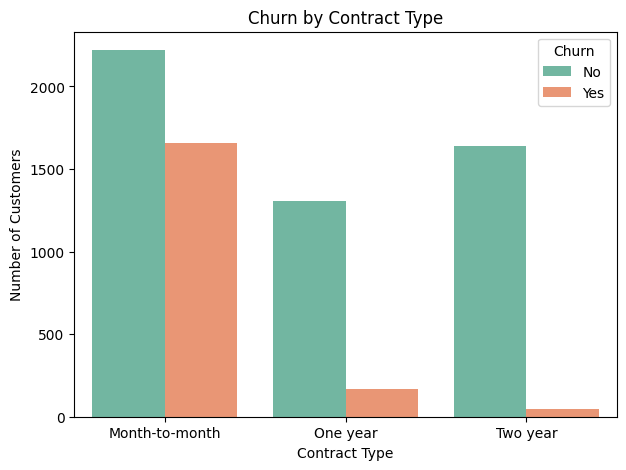

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='Contract', hue='Churn', palette='Set2')
plt.title('Churn by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')
plt.show()

**churn rate by tenure**

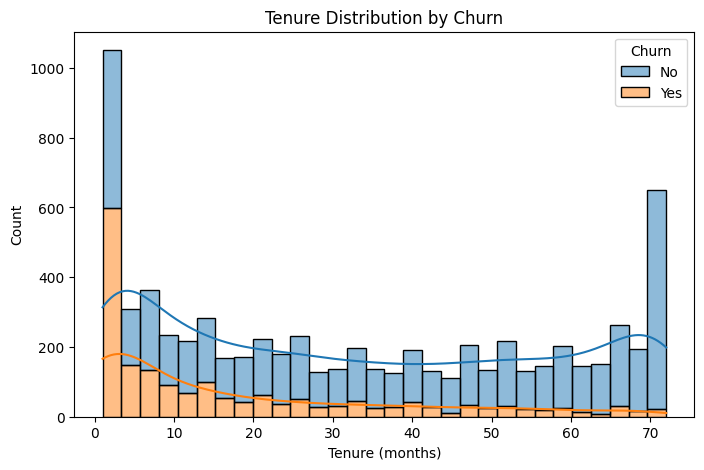

In [7]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='tenure', hue='Churn', bins=30, kde=True, multiple='stack')
plt.title('Tenure Distribution by Churn')
plt.xlabel('Tenure (months)')
plt.show()

**churn rate by monthly charges**

C:\Users\ha626\AppData\Local\Temp\ipykernel_14060\4225359551.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='MonthlyCharges', palette='Set3')


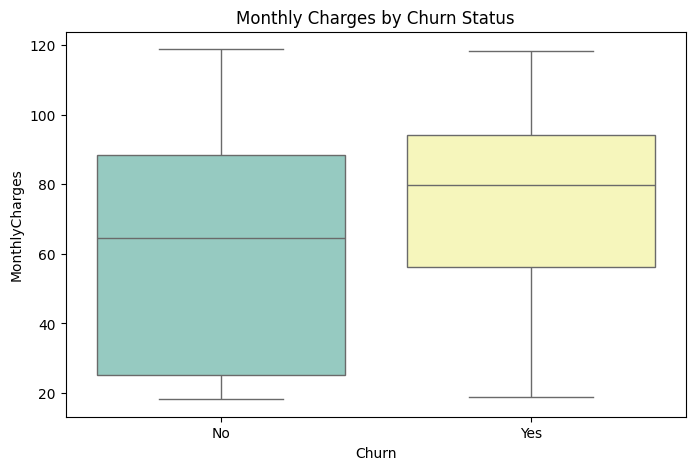

In [8]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', palette='Set3')
plt.title('Monthly Charges by Churn Status')
plt.show()

**class imbalance check**

In [9]:
churn_counts = df['Churn'].value_counts(normalize=True) * 100
print(churn_counts)

Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64


# Prepare data for modeling

In [10]:
df_model = df.drop(columns=['customerID'])
df_model['Churn'] = df_model['Churn'].map({'Yes': 1, 'No': 0})

**one-hot encode remaining categoricals**

In [11]:
categorical_cols = df_model.select_dtypes(include='object').columns.tolist()
print(categorical_cols)

df_model = pd.get_dummies(df_model, columns=categorical_cols, drop_first=True)
df_model.head()

['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


**split**

In [12]:
from sklearn.model_selection import train_test_split

X = df_model.drop(columns=['Churn'])
y = df_model['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

**Logistic Regression**

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)

print("Logistic Regression Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_log):.4f}")
print(classification_report(y_test, y_pred_log, target_names=['No Churn', 'Churn']))

Logistic Regression Results:
Accuracy: 0.8031
              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1033
       Churn       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



d:\NeuroFive Internship\venv\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


**Decision Tree**

In [14]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(max_depth=5, random_state=42)
tree_model.fit(X_train, y_train)
y_pred_tree = tree_model.predict(X_test)

print("Decision Tree Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_tree):.4f}")
print(classification_report(y_test, y_pred_tree, target_names=['No Churn', 'Churn']))

Decision Tree Results:
Accuracy: 0.7783
              precision    recall  f1-score   support

    No Churn       0.85      0.84      0.85      1033
       Churn       0.58      0.60      0.59       374

    accuracy                           0.78      1407
   macro avg       0.72      0.72      0.72      1407
weighted avg       0.78      0.78      0.78      1407



**side-by-side comparison table**

In [15]:
from sklearn.metrics import precision_score, recall_score, f1_score

comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree'],
    'Accuracy': [accuracy_score(y_test, y_pred_log), accuracy_score(y_test, y_pred_tree)],
    'Precision (Churn)': [precision_score(y_test, y_pred_log), precision_score(y_test, y_pred_tree)],
    'Recall (Churn)': [recall_score(y_test, y_pred_log), recall_score(y_test, y_pred_tree)],
    'F1-score (Churn)': [f1_score(y_test, y_pred_log), f1_score(y_test, y_pred_tree)]
})
comparison

,Model,Accuracy,Precision (Churn),Recall (Churn),F1-score (Churn)
0,Logistic Regression,0.803127,0.645646,0.574866,0.608204
1,Decision Tree,0.778252,0.580729,0.596257,0.588391


**Top 3 features driving churn**

                        Feature  Importance
1                        tenure    0.441283
10  InternetService_Fiber optic    0.338826
3                  TotalCharges    0.033886


C:\Users\ha626\AppData\Local\Temp\ipykernel_14060\1315265487.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importances.head(10), x='Importance', y='Feature', palette='viridis')


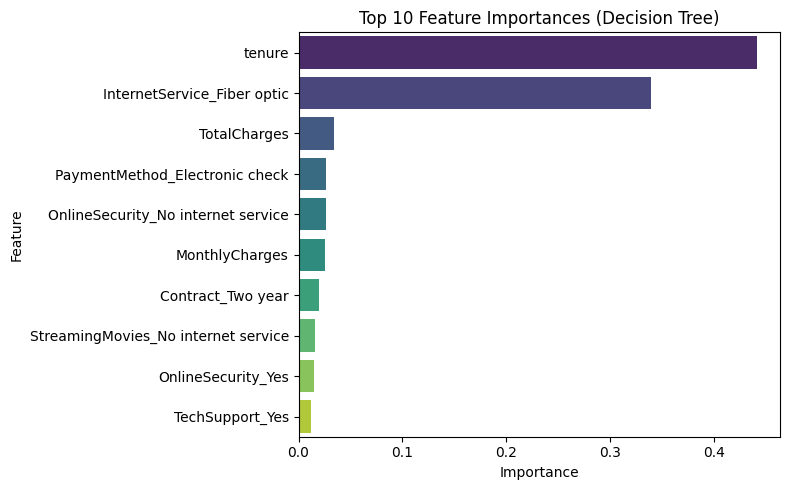

In [16]:
importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': tree_model.feature_importances_
}).sort_values('Importance', ascending=False)

top_3 = importances.head(3)
print(top_3)

plt.figure(figsize=(8, 5))
sns.barplot(data=importances.head(10), x='Importance', y='Feature', palette='viridis')
plt.title('Top 10 Feature Importances (Decision Tree)')
plt.tight_layout()
plt.show()

## Business Summary

Our analysis shows that customer churn is strongly linked to [feature 
1], [feature 2], and [feature 3] — for example, customers on 
month-to-month contracts with shorter tenure and higher monthly 
charges are significantly more likely to leave. The Decision Tree 
model correctly identifies churners [X]% of the time, giving the 
business a practical early-warning tool. Since only about 27% of 
customers actually churn in this dataset, we prioritized recall — 
catching as many true churners as possible — over simple accuracy, 
since missing a churner costs more than a false alarm. We recommend 
targeting retention offers at customers matching this at-risk 
profile, particularly those still in their first year on a 
month-to-month plan.